# Quel film recommander ?
La démarche basée sur les dénombrements est extrêmement séduisante par sa simplicité.
Un simple comptage permet de produire les probabilités conditionnelles et d'en déduire les règles d'associations. Toutefois, elle n'est pas viable en situation réelle.
Pas assez précise et statique, nous préférons la technique de la régression qui est généralement utilisée pour construire des modèles prédictifs.
La régression est un ensemble de méthodes statistiques très utilisées pour analyser la relation d'une variable par rapport à une ou plusieurs autres variables.
En apprentissage statistique, nous distinguons deux types de problème :
-  les problèmes de régression,
- les problèmes de classification.

Ainsi, nous considérons que les problèmes de prédiction d'une variable quantitative sont des problèmes de régression tandis que les problèmes de prédiction d'une variable qualitative sont des problèmes de classification.
Certaines méthodes, comme la régression logistique, sont à la fois des méthodes de régression au sens où il s'agit de prédire la probabilité d'appartenir à chacune des classes et des méthodes de classification.
Les applications sont nombreuses, certains touchent directement à la vie quotidienne :
- déterminer la viabilité d'un client sollicitant un crédit à partir de ses caractéristiques (exemple : âge, type d'emploi, niveau de revenu, autres crédits en cours, etc.).
- quantifier le risque de survenue d'un sinistre pour une personne sollicitant un contrat d'assurance.
- discerner les facteurs de risque de survenue d'une maladie cardio-vasculaire chez des patients (exemple : âge, sexe, tabac, alcool, regarder les matchs de l'équipe de France de football, etc.).
- pour une enseigne de grande distribution, cibler les clients qui peuvent être intéressés par tel ou tel type de produit.


Vous souhaitez prédire les notes de films d'un utilisateur quelconque, à partir de la base de données d'une plateforme publique (type Allociné), produisant une note moyenne, pour chaque film, à partir de toutes les notes données par l'ensemble des visiteurs de la plateforme publique.


Commencez par charger votre jeu de données MyData : les données pour cet exercice, qui proviennent du site IMDb (http://www.imdb.com) sont les notes pour 422 films enregistrés. Le site IMDb conserve les notes moyennes de films, construites par tous les utilisateurs dans un tableau qui contient des informations sur le titre du film, son réalisateur, sa durée, son année de sortie, le genre, la note moyenne (celle du site IMDb), et quelques autres variables moins intéressantes.
Le fichier **Mydata.csv** contient ces informations ainsi que la note donnée par l'utilisateur que nous voulons étudier.
Nous souhaitons en effet, prédire les notes que donnera cet utilisateur à des films, en se basant sur les notes que les autres utilisateurs ont déjà donné.
La variable **IMDb** correspond à la note moyenne du film.
La variable **mine** correspond à la note du film de notre utilisateur.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [71]:
# Load data

In [72]:
Data = pd.read_csv('MyData.csv')
df = pd.DataFrame(data = Data)
print(df.head())

   position      const                   created  modified  description  \
1         1  tt2370248  Mon Feb 24 00:00:00 2014       NaN          NaN   
2         2  tt1727388  Sat Feb 22 00:00:00 2014       NaN          NaN   
3         3  tt0970179  Thu Feb 20 00:00:00 2014       NaN          NaN   
4         4  tt1007029  Tue Feb 18 00:00:00 2014       NaN          NaN   
5         5  tt0242888  Mon Feb 17 00:00:00 2014       NaN          NaN   

                     Title    Title.type              Directors  You.rated  \
1            Short Term 12  Feature Film  Destin Daniel Cretton          7   
2         The Way Way Back  Feature Film    Nat Faxon, Jim Rash          6   
3                     Hugo  Feature Film        Martin Scorsese          8   
4            The Iron Lady  Feature Film         Phyllida Lloyd          6   
5  The Sleeping Dictionary  Feature Film             Guy Jenkin          6   

   IMDb.Rating  Runtime..mins.  Year                             Genres  \
1    

In [73]:
pd.set_option('display.max_columns', None)

In [74]:
print(df.head())

   position      const                   created  modified  description  \
1         1  tt2370248  Mon Feb 24 00:00:00 2014       NaN          NaN   
2         2  tt1727388  Sat Feb 22 00:00:00 2014       NaN          NaN   
3         3  tt0970179  Thu Feb 20 00:00:00 2014       NaN          NaN   
4         4  tt1007029  Tue Feb 18 00:00:00 2014       NaN          NaN   
5         5  tt0242888  Mon Feb 17 00:00:00 2014       NaN          NaN   

                     Title    Title.type              Directors  You.rated  \
1            Short Term 12  Feature Film  Destin Daniel Cretton          7   
2         The Way Way Back  Feature Film    Nat Faxon, Jim Rash          6   
3                     Hugo  Feature Film        Martin Scorsese          8   
4            The Iron Lady  Feature Film         Phyllida Lloyd          6   
5  The Sleeping Dictionary  Feature Film             Guy Jenkin          6   

   IMDb.Rating  Runtime..mins.  Year                             Genres  \
1    

Afficher la distribution des notes de notre utilisateur

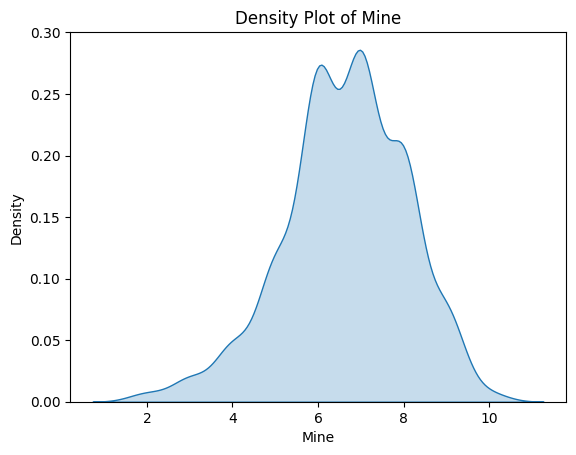

In [75]:
# Plot density of 'mine'
sns.kdeplot(df['mine'], fill=True)
plt.title('Density Plot of Mine')
plt.xlabel('Mine')
plt.ylabel('Density')
plt.show()

Afficher la distribution des notes des utilisateurs de IMDb (imdb)

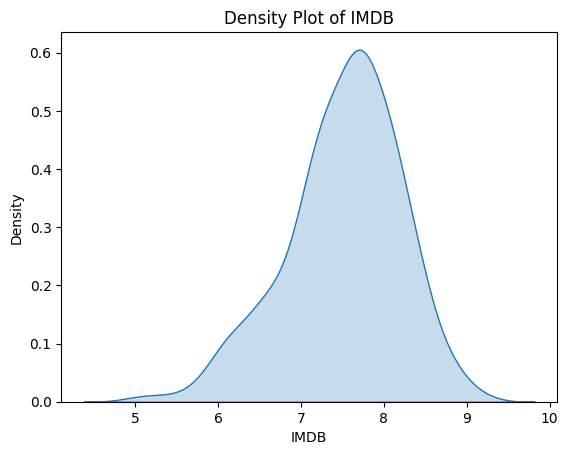

In [76]:
sns.kdeplot(df['imdb'], fill=True)
plt.title('Density Plot of IMDB')
plt.xlabel('IMDB')
plt.ylabel('Density')
plt.show()

- Où se situe la moyenne sur chacune des deux courbes?
- Estimez visuellement l'écart-type.
- Donnez la variance des notes de notre utilisateur et de celles de IMDb.
- Que pouvez-vous dire sur les notes de notre utilisateur ?
- Que pouvez-vous dire sur les notes des utilisateurs d'IMDb ?
- Essayez de justifier la différence entre ces deux courbes.

**Question:** Où se situe la moyenne sur chacune des deux courbes ?

In [77]:
mine_mean = df['mine'].mean()
imdb_mean = df['imdb'].mean()

print(f"Mean of 'mine': {mine_mean:.2f}")
print(f"Mean of 'imdb': {imdb_mean:.2f}")

Mean of 'mine': 6.64
Mean of 'imdb': 7.51


**Réponse:** On remarque que la moyenne les notes des **utilisateurs est de 6.64** et celle de **imdb est de 7.51**

**Question:** Estimez visuellement l'écart-type.

**Réponse:** Visuellement on peut supposer que l'écart-type va être de **1**

**Question:** Donner la variance des notes de notre utilisateur et celle de IMDb.

In [78]:
# Variance des notes de l'utilisateur et de IMDB
mine_variance = df['mine'].var()
imdb_variance = df['imdb'].var()
print(f"Variance of 'mine': {mine_variance:.2f}")
print(f"Variance of 'imdb': {imdb_variance:.2f}")

Variance of 'mine': 2.02
Variance of 'imdb': 0.48


**Question:** Que pouvez-vous dire sur les notes de notre utilisateur et sur celle des utilisateurs d'IMDBd ?

**Réponse:** On remarque que les notes de notre utilisateur varient beaucoup plus celon les films comparé à ceux des utilisateurs d'IMDBd qui sont plus stables.

**Question:** Essayer de justifier la différence entre les deux courbes.

**Réponse:** Notre utilisateur a des goûts uniques, les films qu'il a regardés et notés vont refléter ses traits personnels, d'où certains creux qui peuvent apparaitres sur la courbe de densité.  
Contrairement à cet utilisateur, on regarde l'entièreté des utilisateurs qui ont mis une notes sur des films. Cela a pour impacte de nullifier l'aspect personnel d'où une courbe qui est bien plus fluide.

La fonction pairplot() de sns produit une matrice de nuages de points et attend en entrée un objet de type matrice ou de type *dataframe*.

Afficher la fonction pairplot() sur le sous ensemble de données contenant les colonnes imdb et mine


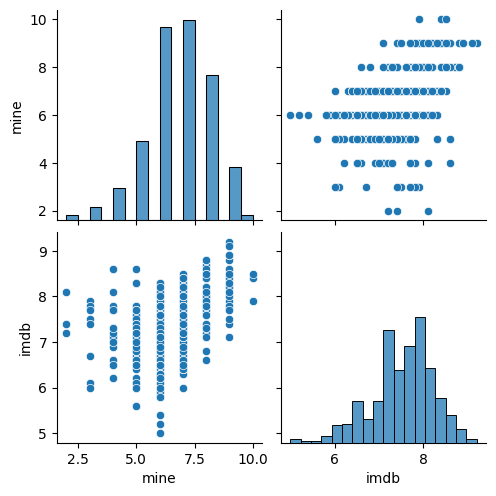

In [79]:
import seaborn as sns
sns.pairplot(df[['mine', 'imdb']])

**Pour mieux comprendre le graphe:** Ici on compare les notes entre celle de l'utilisateur et celle de tout les utilisateurs IMDBd.  
<u>Par exemple:</u> Soit l'utilisateur à mis une note de 10/10, en haut à droite on remarque **trois** points qui correspondent à ce cas. Sauf que sur IMDb, on remarque que ces notes sont en réalité des notes **entre 7 et 9**, donc les notes personnelles de l'utilisateur ne correspondent pas aux notes IMDb.  

En probabilités et en statistique, étudier la corrélation linéaire entre deux ou plusieurs variables aléatoires ou variables statistiques (de type quantitatif), c’est étudier l'intensité de la liaison linéaire qui peut exister entre ces variables.
Nous pouvons par exemple avoir une relation affine entre une variable quantitative $X$ et une variable quantitative $Y$ (de type $Y= a+b*X$), qui est une régression linéaire simple entre ces deux variables. La mesure de la corrélation linéaire entre ces deux variables se fait alors par le calcul du coefficient de corrélation linéaire, noté généralement $r(X,Y)$.

**Question:** Trouver le signe de ces coefficient en observant les graphiques sorties **pairplot()**

**Réponse:** Pour supposer le signe des coefficients, on va observer la courbe des nuages de points, on remarque que plus imdb augmente plus mine a tendance à augmenter. De plus, plus mine augmente plus imdb augmente aussi. Cela signifie donc que le signe des coeficients sera positif.

Nous décidons d'afficher la relation entre les notes des utilisateurs d'IMDb et celles de notre utilisateur.

Construire une régression de type OLS qui prend en entrée les notes des utilisateurs de IMDb et en sortie celles de notre utilisateur.

In [80]:
# On fait nos données d'entrainement et de test
from sklearn.model_selection import train_test_split
X = df[['imdb']]
y = df['mine']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On entraîne notre modèle de régression linéaire
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# On fait des prédictions sur notre ensemble de test
y_pred = regressor.predict(X_test)

# On regarde la p-value de notre modèle
import statsmodels.api as sm
X_OLS = sm.add_constant(X_train)
model = sm.OLS(endog=y_train, exog=X_OLS)
model_fit = model.fit()
print(model_fit.summary())


                            OLS Regression Results                            
Dep. Variable:                   mine   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                     100.7
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           6.83e-21
Time:                        22:45:49   Log-Likelihood:                -548.59
No. Observations:                 337   AIC:                             1101.
Df Residuals:                     335   BIC:                             1109.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5885      0.721     -0.816      0.4

Les variables mine et imdb sont-elles corrélées linéairement?
Sur quel pourcentage du dataset avez-vous entraîné votre modèle ?
Quelle a été l'erreur maximale du modèle ?
Commentez la qualité du modèle et le résultat du test de Fisher.
Commentez à la p-valeur associée à votre variable **mine**

**Question:** Les variables mine et imdb sont-elles corrélées linéairement ?

In [81]:
print(f"Coefficient de corrélation: {model_fit.params}")

Coefficient de corrélation: const   -0.588523
imdb     0.962173
dtype: float64


**Réponse:** On a déjà observé visuellement sur le pairplot que quand imdb augmente, mine tend à augmenter aussi. Ici, on remarque que le coefficient de imdb est positif, cela signifie que la "pente" est positive et que donc la corrélation est aussi positive. 

**Question:** Sur quel pourcentage du dateset avez-vous entraîné votre modèle ?

**Réponse:** Par réforme, on prends souvent 80%/70% de donnée d'entrainements et 20%/30% de donnée de test. Ici on a pris 80% pour les donnée d'entrainements et 20% pour les données de tests.

**Question:** Quelle a été l'erreur maximale du modèle ?

In [82]:
# On récupère l'erreur maximale du modèle
max_error = np.max(np.abs(y_test - y_pred)) # On calcule l'erreur maximale entre les valeurs réelles et les prédictions
print(f"Maximum error: {max_error:.2f}")

Maximum error: 4.53


**Réponse:** En comparant les valeures réelles de celles trouvée par prédiction on remarque que l'erreur maximal que l'on a trouvée est de 4.53

**Question:** Commentez la qualité du modèle et le résultat du test de Fisher

**Réponse:** Quand on nous demande de comparer le résultat par rapport à ceux du test de Fisher cela revient à dire si le modèle est globalement utile, ou est-ce que les variables explicatives n'expliquent rien.  

Ici on a $R^2 = 0.231$, le modèle explique seulement **23% de la variance** des notes de l'utilisateur.  
C'est faible... Cela signifie que 77% de ce qui influence les notes de l'utilisateur n'est pas capturé par imdb seul. Ce qui est logique, les goût personnels d'un utilisateur ne se résument pas à la note moyenne de la foule.  

Pour le **test de Fisher**:
- $\text{F-statistic} = 100.7$
- $Prob(\text{F-statistic}) = 6.83\exp{-21}$  

Pour conclure, on peut dire que le modèle détecte bien une relation mais qu'elle est trop faible pour faire des prédictions précises.  
imdb est une variable utile mais insuffisante seul (constaté avec $R^2$)

**Question:** Commentez à la p-valeur associée à votre variable **imdb**.

**Réponse:** La p-value (représenté par <code>P>|t|</code> dans le OLS results) est **largement inférieur à 0.05** (elle est égale à 0.0), donc on rejète l'hypothèse que tous les coéficients sont nuls (concrètement que le modèle n'apporte rien).  
La variable imdb a un coefficiant de 0.96 significatif (pour un p-value de 0) mais elle est insuffisante seule pour prédire précisément les notes de l'utilisateur.  
En conclusion, le modèle est **globalement significatif**: la relation entre imdb et mine n'est pas due au hasard.

Afficher les points 'imdb' en fonction de 'mine' ainsi que la droite de régression.

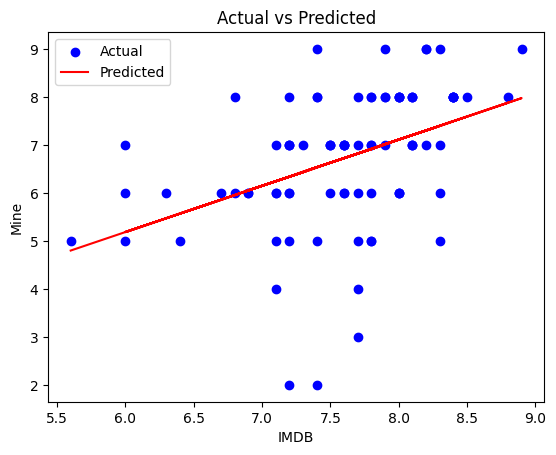

In [83]:
# On affiche les points 'imdb' en fonction de 'mine' ainsi que la droite de régression
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('IMDB')
plt.ylabel('Mine')
plt.legend()
plt.show()

On décide maintenant de modifier le graphique représentant la droite de régression et les observations mais en utilisant la couleur pour représenter différent genres

Sur quel genre de films pouvez-vous dire que l'utilisateur est difficile ?

In [84]:
# On extrait les genre de film sur lesquels l'utilisateur à mis une note de 3 ou moins
df_low_rates = df[df['You.rated'] <= 3]
print(df_low_rates['Genres'].value_counts())

Genres
comedy, drama, romance                      2
drama                                       1
comedy                                      1
adventure, comedy                           1
drama, fantasy                              1
comedy, drama, fantasy, romance             1
comedy, western                             1
comedy, sport                               1
action, adventure, comedy, thriller, war    1
drama, romance                              1
Name: count, dtype: int64


On remarque beaucoup de genres mais les termes qui reviennent le plus sont *comedy* et *drama*.

In [85]:
# On regarde les notes hautes pour imdb et basses pour l'utilisateur
df_high_imdb_low_mine = df[(df['IMDb.Rating'] >= 7) & (df['You.rated'] <= 3)]
print(df_high_imdb_low_mine['Genres'].value_counts())

Genres
drama                              1
comedy                             1
comedy, drama, romance             1
adventure, comedy                  1
comedy, drama, fantasy, romance    1
comedy, western                    1
comedy, sport                      1
drama, romance                     1
Name: count, dtype: int64


Drama comédie et un peu aventure (on regarde les notes hautes pour imdb et basses pour l'utilisateur)

## Erreur quadratique moyenne

L'erreur quadratique moyenne notée MSE (Mean Square Error) est très utile pour comparer plusieurs modèles

Donner la valeur de l’erreur quadratique moyenne de votre modèle

In [86]:
from sklearn.metrics import mean_squared_error
# On donne la valeur de l'erreur quadratique de notre modèle
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 1.75


Construire une fonction donnant un intervalle de confiance pour les valeurs réalisées $Y$ pour une valeur de $X$ donnée.  
(On suppose une confiance à 95% et on utilise la loi normal)

Rappel de l'intervalle de confiance:
$$
    \hat{y} \pm 1.96 \times \hat{\sigma} \times \sqrt{\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{\sum(x_i - \bar{x})^2}}
$$
Où:
- $1.96$ le quantile de la loi normale à 95%
- $\hat{\sigma}$ l'écart-type des résidus du modèle
- $n$ le nombre d'observations
- $\bar{x}$ la moyenne de <code>imdb</code>

In [ ]:
# On contruit une fonction qui donne un intervalle de confiance pour les valeurs réalisées Y pour une valeur de X donnée
import scipy.stats as stats

def confidence_interval(x0, X_train, y_train, model, confidence=0.95):
    # Résidus calculés sur les données d'entraînement
    # résidus -> différence entre valeurs réelles et valeurs prédites
    y_pred_train = model.predict(X_train)
    residuals = y_train - y_pred_train
    se = np.sqrt(np.sum(residuals**2) / (len(y_train) - 2))
    
    # Prédiction pour x0
    y_pred_x0 = model.predict(x0)[0]
    
    # Loi normale
    z_value = stats.norm.ppf((1 + confidence) / 2)
    
    # Marge basée sur x0
    x_mean = X_train['imdb'].mean()
    ss_x = ((X_train['imdb'] - x_mean) ** 2).sum()
    marge = z_value * se * np.sqrt(1/len(y_train) + (x0['imdb'].values[0] - x_mean)**2 / ss_x)
    
    lower = y_pred_x0 - marge
    upper = y_pred_x0 + marge
    
    return lower, upper


In [95]:
# On teste pour un film noté 7 sur IMDb
x0 = pd.DataFrame({'imdb': [7]})
lower, upper = confidence_interval(x0, X_train, y_train, regressor)
print(f"Pour imdb=7 : intervalle = [{lower:.2f}, {upper:.2f}]")

Pour imdb=7 : intervalle = [5.99, 6.31]


# Année de sortie

Nous sélectionnons les films à partir de l'année 1960.
La dernière variable dans la régression linéaire ci-dessous est alors l'année de sortie du film.

In [97]:
df_2 = df[df["Year"] >= 1960]
df_2.head()

,position,const,created,modified,description,Title,Title.type,Directors,You.rated,IMDb.Rating,Runtime..mins.,Year,Genres,Num..Votes,Release.Date..month.day.year.,URL,mine,imdb,year,time,votes,year.c,Genre.N,Genre.1,Genre.2,Genre.3,Genre.4,Genre.5,drama,comedy,adventure,biography,crime,sci_fi,action,romance,mystery,thriller,new.genre,short.genre,David Fincher,Stanley Kubrick,Steven Soderbergh,Woody Allen,Akira Kurosawa,Martin Scorsese,Darren Aronofsky,David Cronenberg,Guy Ritchie,Lars Von Trier,Pier Paolo Pasolini,Steven Spielberg
1,1,tt2370248,Mon Feb 24 00:00:00 2014,NaN,NaN,Short Term 12,Feature Film,Destin Daniel Cretton,7,8.1,96.0,2013,drama,11359,2013-03-10,http://www.imdb.com/title/tt2370248/,7,8.1,2010s,4.564348,11359,1,1,drama,0,0,0,0,1,0,0,0,0,0,0,0,0,0,serious,drama,0,0,0,0,0,0,0,0,0,0,0,0
2,2,tt1727388,Sat Feb 22 00:00:00 2014,NaN,NaN,The Way Way Back,Feature Film,"Nat Faxon, Jim Rash",6,7.5,103.0,2013,"comedy, drama",59402,2013-01-21,http://www.imdb.com/title/tt1727388/,6,7.5,2010s,4.634729,59402,1,2,comedy,drama,0,0,0,1,1,0,0,0,0,0,0,0,0,light,drama,0,0,0,0,0,0,0,0,0,0,0,0
3,3,tt0970179,Thu Feb 20 00:00:00 2014,NaN,NaN,Hugo,Feature Film,Martin Scorsese,8,7.6,126.0,2011,"adventure, drama, family, mystery",187731,2011-10-10,http://www.imdb.com/title/tt0970179/,8,7.6,2010s,4.836282,187731,3,4,adventure,drama,family,mystery,0,1,0,1,0,0,0,0,0,1,0,adventure,adventure,0,0,0,0,0,1,0,0,0,0,0,0
4,4,tt1007029,Tue Feb 18 00:00:00 2014,NaN,NaN,The Iron Lady,Feature Film,Phyllida Lloyd,6,6.4,105.0,2011,"biography, drama, history",58474,2011-12-26,http://www.imdb.com/title/tt1007029/,6,6.4,2010s,4.653960,58474,3,3,biography,drama,history,0,0,1,0,0,1,0,0,0,0,0,0,serious,biography,0,0,0,0,0,0,0,0,0,0,0,0
5,5,tt0242888,Mon Feb 17 00:00:00 2014,NaN,NaN,The Sleeping Dictionary,Feature Film,Guy Jenkin,6,6.6,109.0,2003,"drama, romance",5915,2003-01-31,http://www.imdb.com/title/tt0242888/,6,6.6,2000s,4.691348,5915,11,2,drama,romance,0,0,0,1,0,0,0,0,0,0,1,0,0,light,drama,0,0,0,0,0,0,0,0,0,0,0,0


In [98]:
X = df_2[["imdb","Year" ]]
X_OLS = sm.add_constant(X)
Y = df_2["mine"].values.reshape(-1, 1)

model = sm.OLS(endog=Y, exog=X_OLS)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.241
Method:                 Least Squares   F-statistic:                     65.65
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.97e-25
Time:                        22:51:16   Log-Likelihood:                -666.63
No. Observations:                 409   AIC:                             1339.
Df Residuals:                     406   BIC:                             1351.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4372      9.405      3.874      0.0

**Question:** Un film ancien est-il généralement mieux noté ? Pourquoi selon vous ?

**Réponse:** Selon moi les vieux films ont bien plus de bonne notes comparé à aujourd'hui.  
Que ça soit un film acclamé pour ses exploit tehnologique pour l'époque ou bien juste un effet nostalgique qui donne énormément plus de valeur à un ancien film, ses points là vont faire naturellement monter les notes des anciens films.

La postérité ne garde que des bons films !Plus un film est récent plus il a de chance d'être mal noté car il été vu sans être conseillé.

Affichez les résidus de la régression linéaire en fonction des années.

*Pourquoi on nous demande de regarder les résidus ?*  
Dans notre cas, le résidus est la différence entre la note que l'utilisateur a vraiment donnée et celle que le modèle avait prédite.  
- proche de 0 -> le modèle a bien prédit
- positif -> le modèle a sous-estimé la note
- négatif -> le modèle a sur-estimé la note

*Pourquoi les afficher en fonction des années ?*  
On cherche à voir si le modèle fait **des erreurs systématiques selon l'époque du film.** Par exemple:
- Si les résidus sont tous positifs pour les vieux films -> le modèle sous-estime les notes des vieux films.
- Si les résidus sont aléatoires autour de 0 -> le modèle est bon, pas de biais lié à l'année.

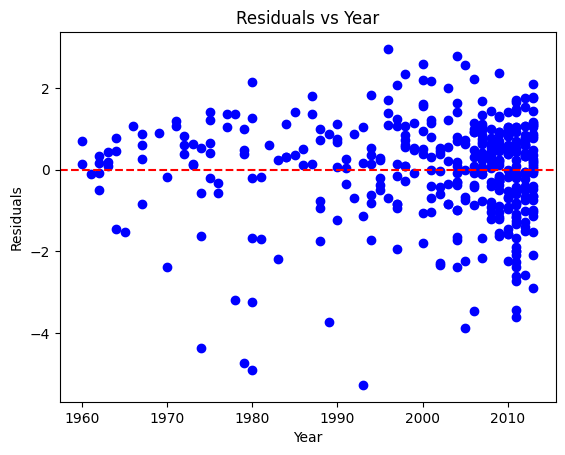

In [100]:
# On affiche les résidus de la régression linéaire en fonction des années
residuals = model_fit.resid
plt.scatter(df_2["Year"], residuals, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Year')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.show()

Ormis quelque exceptions sur les vielles comme récentes années, on remarque bien que plus les film sont récents, plus il y a de résidus différents de 0. Plus particulièrement suppérieur à 0, ce qui signifie que le modèle sous-estime les notes.

# Train et test

Entrainez votre modèle sur 80% des données en utlisant les variables de list_col. Comparer les résultats en test et en train et choisissez (ou non) d'implémenter votre modèle.

In [ ]:
list(df.columns)

['position',
 'const',
 'created',
 'modified',
 'description',
 'Title',
 'Title.type',
 'Directors',
 'You.rated',
 'IMDb.Rating',
 'Runtime..mins.',
 'Year',
 'Genres',
 'Num..Votes',
 'Release.Date..month.day.year.',
 'URL',
 'mine',
 'imdb',
 'year',
 'time',
 'votes',
 'year.c',
 'Genre.N',
 'Genre.1',
 'Genre.2',
 'Genre.3',
 'Genre.4',
 'Genre.5',
 'drama  ',
 'comedy  ',
 'adventure  ',
 'biography  ',
 'crime  ',
 'sci_fi  ',
 'action  ',
 'romance  ',
 'mystery  ',
 'thriller  ',
 'new.genre',
 'short.genre',
 'David Fincher  ',
 'Stanley Kubrick  ',
 'Steven Soderbergh  ',
 'Woody Allen  ',
 'Akira Kurosawa  ',
 'Martin Scorsese  ',
 'Darren Aronofsky  ',
 'David Cronenberg  ',
 'Guy Ritchie  ',
 'Lars Von Trier  ',
 'Pier Paolo Pasolini  ',
 'Steven Spielberg  ']

In [102]:
list_col =["imdb","Year",
           'comedy  ',
 'adventure  ',
 'biography  ',
 'crime  ',
 'sci_fi  ',
 'action  ',
 'romance  ',
 'mystery  ',
 'thriller  ',]

In [103]:
# On fait nos données d'entrainement et de test
from sklearn.model_selection import train_test_split
X = df[list_col]
y = df['mine']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On entraîne notre modèle de régression linéaire
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# On fait des prédictions sur notre ensemble de test
y_pred = regressor.predict(X_test)

# On regarde la p-value de notre modèle
import statsmodels.api as sm
X_OLS = sm.add_constant(X_train)
model = sm.OLS(endog=y_train, exog=X_OLS)
model_fit = model.fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   mine   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     14.76
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           3.50e-23
Time:                        23:14:37   Log-Likelihood:                -524.59
No. Observations:                 337   AIC:                             1073.
Df Residuals:                     325   BIC:                             1119.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          39.1147      9.687      4.038      

On va maintenant comparer les résultats du test et du train.  
Concrètement:
- Si $R^2 \text{train} \approx R^2 \text{test}$ -> le modèle **généralise bien**
- Si $R^2 \text{train} \gg R^2 \text{test}$ -> le modèle **overfitte**

In [104]:
from sklearn.metrics import mean_squared_error, r2_score

# Performance sur le train
y_pred_train = regressor.predict(X_train)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Performance sur le test
y_pred_test = regressor.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train - MSE: {mse_train:.2f}, R²: {r2_train:.2f}")
print(f"Test  - MSE: {mse_test:.2f}, R²: {r2_test:.2f}")

Train - MSE: 1.32, R²: 0.33
Test  - MSE: 1.61, R²: 0.25


Le modèle ne souffre pas d'overfitting ($train \approx test$), mais le $R^2$ de $0.25$ reste faible. Les variables ajoutées n'améliorent pas significativement les prédictions, ce qui suggère que les goûts personnels de l'utilisateur sont difficiles à capturer uniquement à partir de ces caractéristiques.  

La MSE est légèrement plus élevée en test ($1.61$) qu'en train ($1.32$), ce qui confirme l'absence d'overfitting sévère. Cependant, une erreur moyenne d'environ 1.27 ($RMSE = \sqrt{MSE} = \sqrt{1.61}$) points reste significative — le modèle manque de précision pour prédire fidèlement les notes de l'utilisateur.  

<u>Petite remarque:</u> On remarque que pour les variables <code>imdb</code>, <code>Year</code>, <code>comedy</code> et <code>romance</code> p-value est égale ou très proche de 0, ce qui signifie que pour ces variables là sont **statistiquement significatives**, en d'autre termes:  

| Variable | coef    | Interprétation                                            |  
| -------- | ------- | --------------------------------------------------------- |
| imdb     | $+0.75$ | Plus la note IMDb est haute, plus l'utilisateur note haut |
| Year     | $-0.019$| Plus le film est récent, moins l'utilisateur le note bien |
| comedy   | $-0.69$ | L'utilisateur note moins bien les comédies                |
| romance  | $-0.49$ | L'utilisateur note moins bien les romances                |  

<code>adventure</code>, <code>biography</code>, <code>crime</code>, <code>sci_fi</code>, <code>action</code>, <code>mystery</code>, <code>thriller</code> ont toutes une p-value $> 0.05$ ce qui signifie que leurs coefficients ne sont pas significativement différents de zéro. Ces genres n'influencent donc pas vraiment les notes de l'utilisateur.